# 01 · Stop generating the JSON you already know

*Most of a JSON answer is scaffolding that the schema already fixes. `pcd` writes the scaffolding itself and asks the model only for the decisions, nearly all of them in one batched forward pass.*

> **TL;DR**
> - Asked to fill in a 28-field triage schema, a 1.5B model writes the JSON one token at a time: hundreds of sequential forward passes, and only about one token in nine carries a decision. The rest are keys, quotes and commas we could have written ourselves.
> - `pcd` prefills the prompt once, copies its KV cache to one row per field, and reads the decisions from batched passes instead of a generation loop. The whole request takes four forward passes instead of hundreds.
> - The output always has every key and only allowed values. Each field also reports how the model split its belief, and whether it wanted to write something else entirely.
> - This post runs both approaches side by side on the same model and prompt. The next five posts take the engine apart.

All numbers in this series come from running the code in the notebook. The machine and library versions are printed below; timings will differ on your hardware, the ratios should not. Decoding is greedy, so the decisions reproduce exactly.

In [1]:
from nbutils import *
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from pcd import Engine
from pcd.baseline import generate_json, lenient_values

environment()
engine = Engine(load())          # qwen2.5-1.5b, 4-bit MLX
print(engine.backend.describe())

Apple M1 Pro, 16 GB | macOS 15.1.1 | Python 3.13.5 | pcd 0.1.0, mlx 0.32.2, mlx-lm 0.31.3, torch 2.14.0, transformers 5.17.0
{'backend': 'mlx', 'model': 'mlx-community/Qwen2.5-1.5B-Instruct-4bit', 'fast_path': True, 'model_type': 'qwen2'}


## 1. The task

Our running example is the `support_triage` preset: an angry enterprise ticket about a production outage and a double-billed invoice, and a schema of 28 fields that a triage system wants filled in. Every field is either a boolean or a closed set of labels.

In [2]:
preset = load_preset("support_triage")
ticket, schema = preset["context"], preset["schema"]
print(clip(ticket, 520, 160))

SUPPORT TICKET #INC-44019
From: Marcus Vance, CTO @ Omnicorp Global (Tier 1 Strategic Enterprise, k ARR)
Subject: CRITICAL P0: Production US-East API 502 Gateway Outage - Checkout Down

Body: Our primary checkout service has been failing completely for the last 48 minutes because your US-East API endpoint is throwing 502 Bad Gateway errors on every POST /v2/charges call. We are losing approximately ,000 in transaction revenue every ten minutes!

Furthermore, our billing audit discovered this morning that your platf
   [... 338 characters ...]
dge with your VP of Engineering and a full refund of the bogus invoice.

Environment: PRODUCTION
Affected Cluster: us-east-1a
Account Priority: STRATEGIC_TIER_1


In [3]:
kinds = Counter(f["type"] for f in schema.values())
n_labels = sum(len(f.get("choices", [True, False])) for f in schema.values())
print(f"{len(schema)} fields: {kinds['boolean']} booleans, {kinds['enum']} enums, {n_labels} allowed labels in total\n")
for name in ["sentiment", "severity_tier", "sla_breach_risk", "target_resolution_hours"]:
    f = schema[name]
    print(f"{name:25} {f['type']:8} {f.get('choices', [True, False])}")

28 fields: 15 booleans, 13 enums, 84 allowed labels in total

sentiment                 enum     ['VERY_NEGATIVE', 'NEGATIVE', 'NEUTRAL', 'POSITIVE']
severity_tier             enum     ['SEV_0_CRITICAL', 'SEV_1_MAJOR', 'SEV_2_MODERATE', 'SEV_3_MINOR']
sla_breach_risk           boolean  [True, False]
target_resolution_hours   enum     ['1_HOUR', '4_HOURS', '12_HOURS', '24_HOURS']


## 2. The obvious approach: let the model write the JSON

The standard way to get structured output from an LLM is to describe the schema in the prompt and let the model write the object token by token. `pcd` ships this baseline (`pcd.baseline.generate_json`) so we can compare like with like: same model, same prompt, same cached prompt head. Only the decoding differs.

In [4]:
ar = generate_json(engine, ticket, schema)
print(clip(ar.text, 420, 260))

{
  "sentiment": "VERY_NEGATIVE",
  "severity_tier": "SEV_3_MINOR",
  "primary_department": "SECURITY_OPS",
  "secondary_department": "NONE",
  "sla_breach_risk": false,
  "requires_executive_escalation": true,
  "can_resolve_autonomously": false,
  "confidence_above_auto_threshold": false,
  "churn_risk_level": "LOW",
  "refund_recommended": false,
  "refund_tier": "NONE",
  "requires_legal_review": false,
  "securi
   [... 259 characters ...]
e_incident": false,
  "postmortem_required": false,
  "vendor_fault": false,
  "contract_penalty_applicable": false,
  "escalate_to_vp": false,
  "customer_sentiment_trend": "STATIC",
  "suggested_action": "PAGE_ONCALL_SRE",
  "assigned_agent_tier": "TIER_1"
}


In [5]:
print(f"generated tokens : {ar.new_tokens}")
print(f"forward passes   : {ar.forward_passes}  (one per generated token, plus the prompt's prefill and one step the loop runs ahead)")
print(f"valid JSON       : {ar.valid_json}")
print(f"matches schema   : {ar.schema_match}   missing={ar.missing} extra={ar.extra} invalid={ar.invalid}")

generated tokens : 271
forward passes   : 274  (one per generated token, plus the prompt's prefill and one step the loop runs ahead)
valid JSON       : True
matches schema   : False   missing=['ticket_priority'] extra=[] invalid=[]


Two things to notice.

First, the object parses, but it does not match the schema: the model stopped before `ticket_priority`. Nothing in token-by-token generation guarantees every key is present or every value is allowed. You have to validate afterwards and decide what to do with a broken answer.

Second, look at a few of the values. The ticket's subject line says `CRITICAL P0: Production US-East API 502 Gateway Outage`. Here is what the model wrote for the fields that should be obvious:

In [6]:
for k in ["severity_tier", "sla_breach_risk", "churn_risk_level", "root_cause_domain"]:
    print(f"{k:22} {ar.values.get(k)!r}")
bools = [k for k, f in schema.items() if f["type"] == "boolean"]
written = [ar.values[k] for k in bools if k in ar.values]
print(f"\nbooleans written: {Counter(written)}")

severity_tier          'SEV_3_MINOR'
sla_breach_risk        False
churn_risk_level       'LOW'
root_cause_domain      'BILLING_SYNC'

booleans written: Counter({False: 12, True: 3})


We will not call these "wrong" without labelled data, and agreement with a single run is not accuracy. But `SEV_3_MINOR` for a P0 outage is hard to defend. We will come back to what the model believes about these fields when it is asked about each one directly.

## 3. Where the tokens go

Every generated token costs one sequential forward pass through the model. So which tokens actually carry information?

`pcd` can tell us, because it compiles the schema against the tokenizer (post [03](03_compiling_for_the_tokenizer.ipynb) covers how). For each field it knows the exact tokens of the line the model would write, `  "severity_tier": "SEV_0_CRITICAL",\n`, and the first token where the allowed labels start to differ. Everything before that token is fixed by the schema. Everything after it is fixed by the label once that token is chosen. Below, each row is one field of a complete answer (we render the answer `pcd` gives in section 5), and each cell one token.

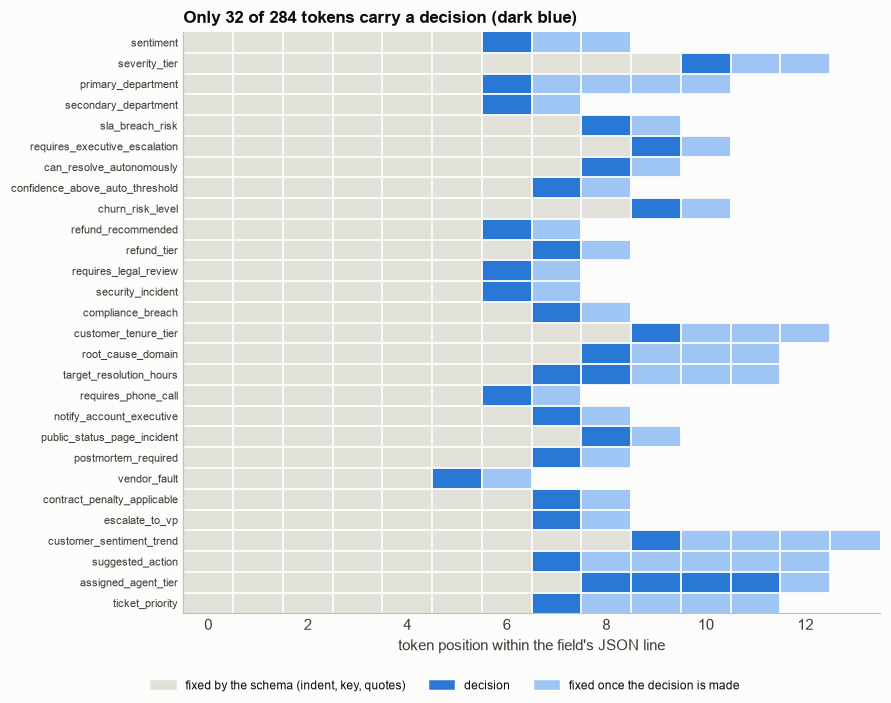

32 decision tokens out of 284 (11%); 28 fields, so 4 extra tokens for labels that share a first token


In [7]:
cs = engine.compile(schema)
answer = engine.extract(ticket, schema).values          # the values we render; section 5 looks at them

SCAFFOLD, DECISION, FORCED = 0, 1, 2
grid, total, decisions = [], 0, 0
for name, cf in cs.fields.items():
    v = next(v for v in cf.variants if cf.labels[v.label] == answer[name])   # canonical form of the answer
    row = [SCAFFOLD] * len(cf.prefix) + [DECISION] * (v.ident + 1) + [FORCED] * (len(v.seq) - v.ident - 1)
    grid.append(row)
    total += len(row)
    decisions += v.ident + 1

width = max(map(len, grid))
img = np.full((len(grid), width), np.nan)
for i, row in enumerate(grid):
    img[i, : len(row)] = row
fig, ax = plt.subplots(figsize=(8.2, 6.4))
ax.imshow(np.ma.masked_invalid(img), cmap=ListedColormap([GRID, SERIES[0], SEQ[1]]), vmin=0, vmax=2, aspect="auto")
ax.set_yticks(range(len(grid)), list(cs.fields), fontsize=7.5)
ax.set_xticks(range(0, width, 2))
ax.set_xticks([x - 0.5 for x in range(1, width)], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, len(grid))], minor=True)
ax.grid(False); ax.grid(which="minor", color=SURFACE, linewidth=1.2)
ax.tick_params(which="both", length=0)
ax.set_xlabel("token position within the field's JSON line")
ax.set_title(f"Only {decisions} of {total} tokens carry a decision (dark blue)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (GRID, SERIES[0], SEQ[1])]
fig.legend(handles, ["fixed by the schema (indent, key, quotes)", "decision", "fixed once the decision is made"],
           loc="lower center", ncol=3, fontsize=8)
plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()
print(f"{decisions} decision tokens out of {total} ({decisions / total:.0%}); "
      f"{len(cs.fields)} fields, so {decisions - len(cs.fields)} extra tokens for labels that share a first token")

Only about one token in nine is a decision. Most fields need exactly one: `NEG` settles `sentiment`, ` true` settles a boolean. Two fields need more because their labels share leading tokens: `1_HOUR` and `12_HOURS` both start with `1`, and `TIER_1` and `TIER_2` agree up to the digit. The model spends the other forward passes writing text that we could have written for it.

Time follows tokens. Here is the baseline's clock:

In [8]:
per_token = ar.decode_ms / ar.new_tokens
print(f"prefill {ar.prefill_ms:.0f} ms | generation {ar.decode_ms:.0f} ms for {ar.new_tokens} tokens ({per_token:.1f} ms/token)")
print(f"share of the generation spent on tokens that carry no decision: ~{1 - decisions / total:.0%}")

prefill 223 ms | generation 2117 ms for 271 tokens (7.8 ms/token)
share of the generation spent on tokens that carry no decision: ~89%


## 4. The idea: write the scaffolding, ask only for the decisions

If we know every token up to each decision, we can skip the generation loop:

1. **Prefill** the shared prompt (instructions, allowed values, the ticket, and an assistant turn that opens the JSON object) once. This is the expensive part, and it is shared by every field.
2. For each field, append the tokens of its line up to the decision position. That gives one short **row** per field.
3. Run all rows in **one batched forward pass**, each on its own copy of the prompt's KV cache, and read the next-token distribution at the end of each row. Restricted to the tokens that start an allowed label, that distribution *is* the decision.

These are the actual rows `pcd` compiled for our schema, with the tokens it will compare at the end of each:

In [9]:
tok = engine.tokenizer
for name in ["sentiment", "severity_tier", "sla_breach_risk", "primary_department", "target_resolution_hours"]:
    cf = cs.fields[name]
    row = "".join(pieces(tok, cf.prefix))
    firsts = sorted({tok.decode([v.seq[0]]) for v in cf.variants})
    print(f"row {vis(row[-34:]):>36}  → compare {', '.join(repr(t) for t in firsts)}")

row                     ··"sentiment":·"  → compare 'NE', 'NEG', 'POS', 'VERY'
row             ··"severity_tier":·"SEV_  → compare '0', '1', '2', '3'
row                 ··"sla_breach_risk":  → compare ' "', ' false', ' true'
row            ··"primary_department":·"  → compare 'BILL', 'ENTER', 'INF', 'LEGAL', 'SEC'
row       ··"target_resolution_hours":·"  → compare '1', '2', '4'


Why is this exact rather than an approximation? Under a causal attention mask, the distribution at the end of a row depends only on the prompt and the row's own tokens. A row sees exactly what the model would have seen had it written the JSON up to that point itself, with one deliberate exception: it does not see the answers to the *other* fields. Fields in the same batch are decided independently. That is the price of parallelism, and posts [04](04_decoding.ipynb) and [06](06_engine_and_benchmarks.ipynb) come back to what it costs and how `pcd` buys some of it back.

Notice also `target_resolution_hours`: two of its labels start with `1`. One token cannot tell `1_HOUR` from `12_HOURS`, so that field needs a second query one token deeper, which still fits in the same batched pass (post [04](04_decoding.ipynb)).

## 5. `pcd` from the outside

This is all a user of the library writes:

In [10]:
engine = Engine(load())                      # or Engine.load("qwen2.5-1.5b"): alias, repo id or local path
out = engine.extract(ticket, schema)
print(out)
print({k: out.values[k] for k in list(out.values)[:6]}, "...")

Extraction(28 fields, 1702 ms, 5 forward passes)
{'sentiment': 'NEGATIVE', 'severity_tier': 'SEV_0_CRITICAL', 'primary_department': 'SECURITY_OPS', 'secondary_department': 'NONE', 'sla_breach_risk': True, 'requires_executive_escalation': True} ...


`out.values` is the object: every key present, in schema order, with real booleans. `out.fields` explains each decision:

In [11]:
md_table(
    ["field", "value", "probability", "candidate mass", "method"],
    [[n, f"`{f.value}`", f"{f.probability:.2f}", f"{f.candidate_mass:.2f}", f.method] for n, f in list(out.fields.items())[:12]],
)
print(f"... {len(out.fields) - 12} more.  methods: {dict(Counter(f.method for f in out.fields.values()))}")

| field | value | probability | candidate mass | method |
|---|---|---|---|---|
| sentiment | `NEGATIVE` | 0.40 | 0.99 | first_token |
| severity_tier | `SEV_0_CRITICAL` | 0.36 | 1.00 | first_token |
| primary_department | `SECURITY_OPS` | 0.71 | 0.79 | first_token |
| secondary_department | `NONE` | 0.75 | 0.93 | first_token |
| sla_breach_risk | `True` | 0.71 | 1.00 | marginal |
| requires_executive_escalation | `True` | 0.90 | 1.00 | marginal |
| can_resolve_autonomously | `False` | 0.92 | 0.97 | marginal |
| confidence_above_auto_threshold | `False` | 0.75 | 0.98 | marginal |
| churn_risk_level | `HIGH` | 0.55 | 0.99 | first_token |
| refund_recommended | `True` | 0.91 | 0.99 | marginal |
| refund_tier | `NONE` | 0.53 | 0.98 | first_token |
| requires_legal_review | `True` | 0.79 | 1.00 | marginal |

... 16 more.  methods: {'first_token': 11, 'marginal': 17}


- **probability** is how the model splits its belief *among the allowed labels*, renormalized. It is not a calibrated confidence.
- **candidate mass** is the unrenormalized probability that the model's next token starts *some* allowed label. A low value means the model wanted to write something outside the schema, which is a good reason to distrust the answer (post [02](02_schemas_and_prompts.ipynb) shows how the prompt keeps it high).
- **method** says how the decision was read: `first_token` when one token decides, `marginal` when the decoder had to look deeper (colliding labels, or booleans the model may write as `"true"`).

And `out.stats` reports what was measured, not what was assumed:

In [12]:
s = out.stats
print(f"prompt tokens {s.prompt_tokens} ({s.cached_tokens} from the cached prompt head)")
print(f"forward passes {s.forward_passes}, rows scored {s.rows_scored}, decode rounds {s.decode_rounds}, waves {s.waves}")
print(f"time: tokenize {s.tokenize_ms:.0f} ms | head prefill {s.head_prefill_ms:.0f} ms | ticket prefill {s.prefill_ms:.0f} ms | "
      f"decode {s.decode_ms:.0f} ms | total {s.total_ms:.0f} ms (includes compiling the schema for this new engine)")
warm = engine.extract(ticket, schema).stats
print(f"second request: {warm.prompt_tokens} prompt tokens ({warm.cached_tokens} from the cache), {warm.forward_passes} forward passes")

prompt tokens 1146 (0 from the cached prompt head)
forward passes 5, rows scored 28, decode rounds 2, waves 2
time: tokenize 25 ms | head prefill 862 ms | ticket prefill 268 ms | decode 548 ms | total 1702 ms (includes compiling the schema for this new engine)
second request: 1146 prompt tokens (901 from the cache), 4 forward passes


Five forward passes for 28 fields on a fresh engine: one prefills the prompt head (the instructions and the list of allowed values), one the ticket, one decides the schema's first field on its own, one short prefill writes that answer into the prompt, and one batched pass decides the other 27. The head is the same for every ticket, so the engine caches it, and from the second request on it is four passes. Why the first field goes alone is a story for post [06](06_engine_and_benchmarks.ipynb).

## 6. Same model, same prompt: do the two decoders agree?

In [13]:
ar_values = lenient_values(schema, ar.values)          # maps "true" -> True etc.; used for agreement only
disagree = [k for k in schema if ar_values.get(k) != out.values[k]]
print(f"agreement: {len(schema) - len(disagree)}/{len(schema)} fields")
md_table(
    ["field", "token by token", "pcd", "pcd probability", "pcd's runner-up"],
    [[k, f"`{ar_values.get(k, '(missing)')}`", f"`{out.values[k]}`", f"{out.fields[k].probability:.2f}",
      f"`{out.fields[k].top[1][0]}` {out.fields[k].top[1][1]:.2f}" if len(out.fields[k].top) > 1 else ""]
     for k in disagree],
)

agreement: 13/28 fields


| field | token by token | pcd | pcd probability | pcd's runner-up |
|---|---|---|---|---|
| sentiment | `VERY_NEGATIVE` | `NEGATIVE` | 0.40 | `VERY_NEGATIVE` 0.39 |
| severity_tier | `SEV_3_MINOR` | `SEV_0_CRITICAL` | 0.36 | `SEV_3_MINOR` 0.35 |
| sla_breach_risk | `False` | `True` | 0.71 | `False` 0.29 |
| churn_risk_level | `LOW` | `HIGH` | 0.55 | `CRITICAL_IMMINENT` 0.37 |
| refund_recommended | `False` | `True` | 0.91 | `False` 0.09 |
| requires_legal_review | `False` | `True` | 0.79 | `False` 0.21 |
| compliance_breach | `False` | `True` | 0.98 | `False` 0.02 |
| root_cause_domain | `BILLING_SYNC` | `API_GATEWAY` | 0.72 | `BILLING_SYNC` 0.16 |
| notify_account_executive | `False` | `True` | 0.59 | `False` 0.41 |
| public_status_page_incident | `False` | `True` | 0.53 | `False` 0.47 |
| postmortem_required | `False` | `True` | 0.79 | `False` 0.21 |
| contract_penalty_applicable | `False` | `True` | 0.56 | `False` 0.44 |
| escalate_to_vp | `False` | `True` | 0.75 | `False` 0.25 |
| customer_sentiment_trend | `STATIC` | `WORSENING` | 0.81 | `IMPROVING` 0.19 |
| ticket_priority | `(missing)` | `P0_EMERGENCY` | 0.97 | `P1_HIGH` 0.02 |

In [14]:
def margin(k):
    top = out.fields[k].top
    return top[0][1] - (top[1][1] if len(top) > 1 else 0.0)

close = [k for k in disagree if margin(k) < 0.1]
firm = [k for k in disagree if out.fields[k].probability >= 0.7]
print(f"near-ties (pcd's top two labels within 0.10): {close}")
print(f"firm (pcd probability >= 0.70):               {firm}")
print(f"booleans: token by token wrote {Counter(written)[True]} true of {len(written)}; "
      f"pcd decided {sum(out.values[k] is True for k in bools)} true of {len(bools)}")

near-ties (pcd's top two labels within 0.10): ['sentiment', 'severity_tier', 'public_status_page_incident']
firm (pcd probability >= 0.70):               ['sla_breach_risk', 'refund_recommended', 'requires_legal_review', 'compliance_breach', 'root_cause_domain', 'postmortem_required', 'escalate_to_vp', 'customer_sentiment_trend', 'ticket_priority']
booleans: token by token wrote 3 true of 15; pcd decided 12 true of 15


They disagree on about half the fields, and the disagreements come in two kinds.

Some are near-ties. Asked about `severity_tier` on its own, the model splits its belief almost evenly between `SEV_0_CRITICAL` and `SEV_3_MINOR`, and the same goes for `sentiment`. A 1.5B model is genuinely unsure there, and it is no surprise that two decoders land on different sides. The per-field probability tells us which fields those are, which token-by-token generation does not.

Most are not. Asked directly, the model is confident that a ticket about a 502 on the API gateway has root cause `API_GATEWAY`, that the customer's sentiment is `WORSENING` and that the priority is `P0_EMERGENCY`, the key the autoregressive run never wrote. While writing the whole object, it drifted into a run of `false`s, and at the end it forgot a key.

This is one ticket and one small model, so treat it as an illustration, not a benchmark: post [06](06_engine_and_benchmarks.ipynb) measures agreement over all presets. It does show the trade-off, though. The autoregressive decoder lets earlier answers influence later ones, for better or for worse. The parallel decoder asks each question in isolation, and every answer it gives is a valid one.

## 7. The bill

Both decoders use the same cached prompt head, so the comparison isolates the decoding method. We time the warm path, the median of three runs each:

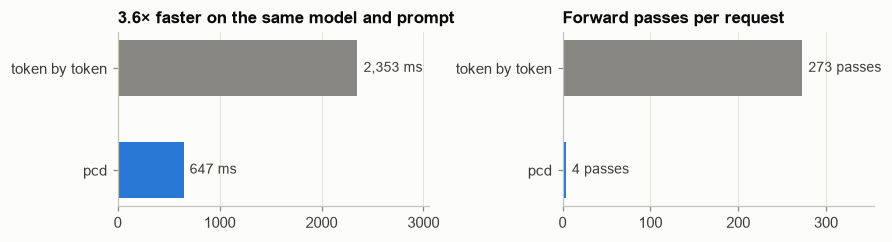

pcd 647 ms vs token by token 2353 ms: 3.6x


In [15]:
pcd_ms, out = timed(lambda: engine.extract(ticket, schema), repeats=3)
ar_ms, ar = timed(lambda: generate_json(engine, ticket, schema), repeats=3)

fig, axes = plt.subplots(1, 2, figsize=(8.2, 2.3))
for ax, vals, unit in [(axes[0], [ar_ms, pcd_ms], "ms"), (axes[1], [ar.forward_passes, out.stats.forward_passes], "passes")]:
    bars = ax.barh(["token by token", "pcd"], vals, color=[MUTED, SERIES[0]], height=0.55)
    ax.bar_label(bars, [f"{v:,.0f} {unit}" for v in vals], padding=4, fontsize=9, color=INK_2)
    ax.invert_yaxis(); ax.grid(axis="y", visible=False); ax.set_xlim(0, max(vals) * 1.3)
axes[0].set_title(f"{ar_ms / pcd_ms:.1f}× faster on the same model and prompt")
axes[1].set_title("Forward passes per request")
plt.tight_layout(); plt.show()
print(f"pcd {pcd_ms:.0f} ms vs token by token {ar_ms:.0f} ms: {ar_ms / pcd_ms:.1f}x")

Most of what remains in `pcd`'s time is prefilling the ticket and the batched pass itself. The generation loop is gone, and with it the dependence on how long the JSON is: 28 fields cost one batched pass, plus the short one for the first field, and so would 50, as long as the rows fit in memory (post [05](05_backends.ipynb) covers the budget).

## 8. What it takes to make this work

The idea fits in a paragraph. Making it correct for any schema, on any model, turned out to be most of the work. Each of these problems gets its own post:

| Problem | What goes wrong if you ignore it | Post |
|---|---|---|
| The model must know which values are allowed | most probability lands outside the labels, and the renormalized "probabilities" are slivers of noise | [02 · What the model reads](02_schemas_and_prompts.ipynb) |
| A row must contain the tokens the model would really write | splits the model never saw in training, `true` scored at ~1e-5, and a missing newline token that adds ~7 nats of noise to every full-string score | [03 · Tokens are not characters](03_compiling_for_the_tokenizer.ipynb) |
| Labels share first tokens; booleans get quoted; some fields have 255 labels | ties broken by fallback rules instead of the model | [04 · Reading decisions off the logits](04_decoding.ipynb) |
| Every architecture has its own cache (sliding windows, linear attention, convolutions), on two frameworks | silent drift between a cached prefix and a fresh one | [05 · Two primitives, every cache](05_backends.ipynb) |
| Fields depend on each other; prompts repeat; costs must be measured | inconsistent answers, wasted prefill, made-up telemetry | [06 · Waves, caches and the bill](06_engine_and_benchmarks.ipynb) |

The code is organised the same way. Everything above the backends is plain Python and NumPy with no framework in sight; only the backends touch MLX or PyTorch, through two methods:

```
Schema ──► PromptFormat ──► compiler ──► decoding ──► Backend (MLX / PyTorch / yours)
fields      chat template     token trie    marginal /     prefill(tokens, parent)
labels      head/tail split   per field     exact / trie   score(prefix, rows, queries)
```

In [16]:
modules = [
    ("schema.py", "fields, labels, dependency waves; dict / JSON Schema / Pydantic input"),
    ("prompt.py", "chat-template rendering, head / context / tail split, catalog"),
    ("compiler.py", "in-context tokenization, decision positions, label tries"),
    ("decoding.py", "first-token / marginal / exact / trie / hybrid decoders"),
    ("engine.py", "compile and prefix caches, waves, stats"),
    ("backends/base.py", "the two-primitive contract, chunk planning"),
    ("backends/mlx_backend.py", "MLX: cache cloning, fast path"),
    ("backends/torch_backend.py", "PyTorch: cache broadcast, fast path"),
    ("testing.py", "conformance checks for any backend"),
]
md_table(["module", "lines", "role"],
         [[f"`{m}`", len((SRC / m).read_text().splitlines()), role] for m, role in modules])

| module | lines | role |
|---|---|---|
| `schema.py` | 305 | fields, labels, dependency waves; dict / JSON Schema / Pydantic input |
| `prompt.py` | 191 | chat-template rendering, head / context / tail split, catalog |
| `compiler.py` | 184 | in-context tokenization, decision positions, label tries |
| `decoding.py` | 298 | first-token / marginal / exact / trie / hybrid decoders |
| `engine.py` | 197 | compile and prefix caches, waves, stats |
| `backends/base.py` | 150 | the two-primitive contract, chunk planning |
| `backends/mlx_backend.py` | 214 | MLX: cache cloning, fast path |
| `backends/torch_backend.py` | 206 | PyTorch: cache broadcast, fast path |
| `testing.py` | 107 | conformance checks for any backend |

## What we learned

- Token-by-token JSON spends nearly all of its forward passes on text the schema already determines. In our example only about one token in nine carries a decision.
- Writing the scaffolding ourselves turns a generation loop into four forward passes per request once the prompt head is cached, with 27 of the 28 fields decided in one batched pass. The output is valid by construction, and every field reports its probability and candidate mass.
- The price is independence: fields decided in the same pass do not see each other's answers. On a small model this changes answers, sometimes for the better.
- The idea is simple; the rest of the series is about the details that make it correct on real tokenizers, real models and real schemas.

Next: [02 · What the model reads](02_schemas_and_prompts.ipynb)